# Introducción

En este trabajo práctico se estudió la estimación espectral de señales mediante la Transformada Discreta de Fourier (DFT), utilizando la Transformada Rápida de Fourier (FFT) como herramienta computacional. El objetivo principal fue analizar cómo se pueden estimar parámetros de una señal a partir de su representación en frecuencia, considerando además el efecto producido por la presencia de ruido.

Para realizar el experimento se generaron distintas realizaciones de una señal senoidal de potencia unitaria, a las cuales se les agregó ruido gaussiano. Se trabajó con 200 realizaciones independientes para poder analizar estadísticamente el comportamiento de los estimadores. Además, se consideraron dos niveles de relación señal-ruido (SNR): 10 dB y 3 dB, permitiendo comparar el comportamiento de los estimadores cuando la señal se encuentra más o menos afectada por el ruido.

Uno de los parámetros a estimar fue la frecuencia de la señal. Para esto se utilizó como estimador la posición del máximo del módulo de la transformada de Fourier:

$$
\hat{\Omega}_i = \arg\max_f |X_i(\Omega)|
$$

De esta manera, para cada realización se buscó el pico máximo del espectro y se utilizó su posición para obtener la frecuencia estimada.

También se estimó la amplitud de la señal a partir del valor del módulo de la FFT correspondiente al pico encontrado. Esto permite obtener una estimación de la amplitud para cada realización y posteriormente analizar su comportamiento mediante parámetros estadísticos como la media, la varianza y el sesgo.

Finalmente, se compararon diferentes ventanas aplicadas previamente al cálculo de la FFT: rectangular, Flattop, Blackman-Harris y Hann. El uso de ventanas permite modificar la forma en que se representa el contenido espectral de una señal y afecta directamente características como la dispersión espectral y la estimación de los parámetros buscados.

El propósito de este trabajo es, por lo tanto, analizar cómo el nivel de ruido y la elección de la ventana utilizada afectan la estimación de frecuencia y amplitud de una señal.

## 1. Experimento con una SNR de 10 dB

Para comenzar el análisis se realizó un experimento considerando una relación señal-ruido de 10 dB. El objetivo es estudiar el comportamiento de los estimadores de frecuencia y amplitud frente a la presencia de ruido y analizar posteriormente el efecto de distintas ventanas sobre la estimación espectral.

Se trabajó con $N=1000$ muestras y una frecuencia de muestreo de $f_s=1000$ Hz. La señal de interés es una sinusoidal de potencia unitaria, con una frecuencia nominal de $250$ Hz. Para cada realización se introdujo además una pequeña variación aleatoria de frecuencia, comprendida entre $-2$ Hz y $2$ Hz.

Se realizaron $R=200$ realizaciones independientes del experimento. De esta manera, en lugar de analizar una única señal, es posible estudiar estadísticamente el comportamiento de los estimadores a partir de los resultados obtenidos en las distintas realizaciones.

### Definición de las variables

En primer lugar se definieron los parámetros principales del experimento, entre ellos la cantidad de muestras, la frecuencia de muestreo, la cantidad de realizaciones, la potencia de la señal y la relación señal-ruido.

Para obtener una señal sinusoidal de potencia promedio igual a $1$ W, considerando una resistencia de $R=1\ \Omega$, se utilizó una amplitud:

$$
A=\sqrt{2}
$$

ya que para una señal sinusoidal se cumple:

$$
P=\frac{A^2}{2R}
$$

De esta manera, con $A=\sqrt{2}$ y $R=1\ \Omega$, la potencia promedio resulta igual a $1$ W.

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Sep 16 12:11:26 2026

@author: joaco
"""

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as sg

#%% Variables

a0 = np.sqrt(2)
N = 1000
omega0 = 250 #en realidad es pi sobre cuatro pero func
Na = 1 #Reemplazar por ruido
fr =  1#cambiarlo por ruido
fs = 1000
R = 200 # Itereaciones del experimento
#varianza = 0.1 aca habria que ver si es esta o la otra

limiteUniforme = 2
P_s = 1 #Potencia
snr_db = 10 #Decibeles
varianza = P_s / (10**(snr_db / 10))
sigma = np.sqrt(varianza)

### Condicionamiento de las variables

Una vez definidos los parámetros principales, se calculó la potencia correspondiente al ruido para obtener una relación señal-ruido de $10$ dB.

La relación señal-ruido se define como:

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right)
$$

Por lo tanto, despejando la potencia de ruido:

$$
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
$$

Considerando que la potencia de la señal es $P_s=1$ W y que la relación señal-ruido es de $10$ dB, se obtiene la varianza utilizada para generar el ruido gaussiano.

El ruido se generó mediante una distribución normal de media cero y desviación estándar $\sigma$, donde:

$$
\sigma=\sqrt{P_n}
$$

Además, para cada una de las $R=200$ realizaciones se generó una variación aleatoria de frecuencia $f_r$ entre $-2$ Hz y $2$ Hz. Por lo tanto, la frecuencia de cada realización queda determinada por:

$$
f_i=f_0+f_{r,i}
$$

donde $f_0=250$ Hz corresponde a la frecuencia nominal.

De esta manera, cada realización posee una frecuencia ligeramente diferente y se encuentra afectada por un ruido gaussiano independiente.

In [2]:
#%% Condicionando las variables

# Hacer las de ruido
Na = np.random.normal(0.0, sigma, (N, R))
# Hecho matriz para poder sumarlo a la funcion sen

fr = np.random.uniform(-limiteUniforme, limiteUniforme, R)
# 200 por la cantidad de iteraciones de expermiento



# Matrices
n_col = np.arange(N).reshape(N, 1)

#omega1 = omega0 + (fr*(2*(np.pi) / N))

omega1 = 2 * np.pi * (omega0 + fr) / N #Cual de los dos estara bien???
# Vos a este lo multiplicas todo por pi por el hecho de que tiene que star en radianes?

omega1 = omega1.reshape(1, R)
# no hace falta el arange en este

### Generación de la señal y cálculo de la FFT

Con los parámetros anteriores se construyó la matriz de señales. Cada columna representa una de las $200$ realizaciones y cada fila corresponde a una muestra temporal.

La señal generada puede expresarse como:

$$
x_i[n]=A\sin(\omega_i n)+n_i[n]
$$

donde $A$ es la amplitud de la señal, $\omega_i$ es la frecuencia angular correspondiente a cada realización y $n_i[n]$ representa el ruido gaussiano.

Posteriormente se calculó la Transformada Rápida de Fourier (FFT) de cada realización. Para ello se utilizó una normalización por la cantidad de muestras $N$:

$$
X_i[k]=\frac{1}{N}\operatorname{FFT}\{x_i[n]\}
$$

A partir del módulo de la FFT se obtuvo el espectro de cada señal.

Para estimar la frecuencia se buscó la posición del máximo del módulo de la FFT:

$$
\hat{f}_i=\underset{f}{\operatorname{arg\,max}}\ |X_i(f)|
$$

Esta expresión permite determinar cuál es la frecuencia que presenta mayor contenido espectral en cada realización.

A partir de la frecuencia estimada se obtuvo también una estimación de la amplitud. Debido a que una señal sinusoidal real presenta componentes simétricas en las frecuencias positiva y negativa, se utilizó:

$$
\hat{A}_i=2|X_i(\hat{f}_i)|
$$

Estos valores de frecuencia y amplitud estimados serán utilizados posteriormente para analizar el sesgo y la varianza de los estimadores.

In [3]:
#%% Creacion de funciones

# Eje de frecuencia
ff_vector = np.fft.fftfreq(N, d=1 / fs)
ff_vector_pos = ff_vector[:N//2]

# Hago mi funcion
f_sen = a0 *np.sin(omega1 * n_col) + Na


#FFt
f_fft = (1/N) * np.fft.fft(f_sen, axis=0)

# Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
potencia_lineal = (np.abs(f_fft[:N // 2, :]))**2
 
dens_pot = 10 * np.log10(potencia_lineal + 1e-12)

# Estimador de frecuencia
indice_pico = np.argmax(np.abs(f_fft[:N // 2, :]), axis=0)

om_f = ff_vector_pos[indice_pico]

# Estimador de amplitud
a_1_2= 2 * np.abs(f_fft[indice_pico, np.arange(R)])

## 2. Aplicación de ventanas

Luego de analizar la señal sin aplicar una ventana, se estudió el efecto de diferentes funciones de ventana sobre la estimación espectral.

La utilización de ventanas permite reducir el leakage espectral producido por la observación de una cantidad finita de muestras. En particular, cuando la frecuencia de la señal no coincide exactamente con uno de los bins de la FFT, parte de la energía de la señal se distribuye sobre frecuencias cercanas.

En este trabajo se analizaron tres ventanas diferentes:

- Ventana Flattop.
- Ventana Blackman-Harris.
- Ventana Hann.

La señal fue multiplicada muestra a muestra por cada ventana antes de realizar nuevamente la FFT.

En forma general, la señal ventaneada puede expresarse como:

$$
x_w[n]=x[n]w[n]
$$

donde $w[n]$ representa la ventana utilizada.

Para cada caso se calculó nuevamente la FFT y se identificó la posición del máximo espectral para obtener la frecuencia estimada.

Además, las ventanas modifican la amplitud del espectro, por lo que para obtener una estimación de amplitud comparable con la señal original se aplicó una corrección utilizando el valor medio de la ventana.

De esta manera, el análisis permite observar cómo diferentes ventanas modifican el espectro y cómo estas modificaciones afectan la estimación de los parámetros de la señal.

In [4]:
#%% Ventanas

#La rectangular ya esta hecha pq es multiplicado por uno

####################################################
#FLATTOP
####################################################

# Genero una funcion que sea la multiplicada por mi ventana
f_flattop =  f_sen * sg.flattop(N).reshape(N, 1)
#Por que se le pone el reshape a este

f_flattop_fft = (1/N) * np.fft.fft(f_flattop, axis=0)

# Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
potencia_lineal_flattop = (np.abs(f_flattop_fft[:N // 2, :]))**2
 
dens_pot_flattop = 10 * np.log10(potencia_lineal_flattop + 1e-12)

# Estimador de amplitud
indice_pico_flattop= np.argmax(np.abs(f_flattop_fft[:N // 2, :]), axis=0)

a_1_2_flattop = (2 * np.abs(f_flattop_fft[indice_pico_flattop, np.arange(R)])) / np.mean(sg.flattop(N))


# Estimador de frecuencia
om_flattop = ff_vector_pos[indice_pico_flattop]

####################################################
#BLACKMANHARRIS
####################################################

# Genero una funcion que sea la multiplicada por mi ventana
f_blackman =  f_sen * sg.blackmanharris(N).reshape(N, 1)
#Por que se le pone el reshape a este

f_blackman_fft = (1/N) * np.fft.fft(f_blackman, axis=0)

# Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
potencia_lineal_blackman = (np.abs(f_blackman_fft[:N // 2, :]))**2
 
dens_pot_blackman = 10 * np.log10(potencia_lineal_blackman + 1e-12)

# Estimador de amplitud
indice_pico_blackman = np.argmax(np.abs(f_blackman_fft[:N // 2, :]), axis=0)

a_1_2_blackman = (2 * np.abs(f_blackman_fft[indice_pico_blackman, np.arange(R)])) / np.mean(sg.blackmanharris(N))

# Estimador de frecuencia
om_blackman = ff_vector_pos[indice_pico_blackman]


####################################################
#HANN
####################################################

# Genero una funcion que sea la multiplicada por mi ventana
f_hann =  f_sen * sg.hann(N).reshape(N, 1)
#Por que se le pone el reshape a este

f_hann_fft = (1/N) * np.fft.fft(f_hann, axis=0)

# Formula de potencia --> elevo al cuadrado y divido por 2 para tener Watts
potencia_lineal_hann = (np.abs(f_hann_fft[:N // 2, :]))**2
 
dens_pot_hann = 10 * np.log10(potencia_lineal_hann + 1e-12)


# Estimador de amplitud
indice_pico_hann = np.argmax(np.abs(f_hann_fft[:N // 2, :]), axis=0)

a_1_2_hann = (2 * np.abs(f_hann_fft[indice_pico_hann, np.arange(R)])) / np.mean(sg.hann(N))


# Estimador de frecuencia
om_hann = ff_vector_pos[indice_pico_hann]




## 3. Análisis de los espectros obtenidos con las distintas ventanas

Una vez calculadas las FFT correspondientes a cada ventana, se representaron los espectros obtenidos para las 200 realizaciones.

En estos gráficos se puede observar la distribución de la energía de la señal alrededor de su frecuencia principal. Debido a que la frecuencia de cada realización presenta una pequeña variación aleatoria, los máximos espectrales no se encuentran exactamente en la misma posición.

La comparación entre las distintas ventanas permite observar cómo cambia la forma del pico principal y la cantidad de energía que aparece distribuida en las frecuencias cercanas.

La ventana rectangular corresponde al caso sin procesamiento adicional, mientras que las ventanas Flattop, Blackman-Harris y Hann modifican la forma del espectro de acuerdo con sus características.

Los gráficos permiten analizar visualmente el compromiso existente entre la concentración de energía alrededor del pico principal y la presencia de componentes espectrales laterales.

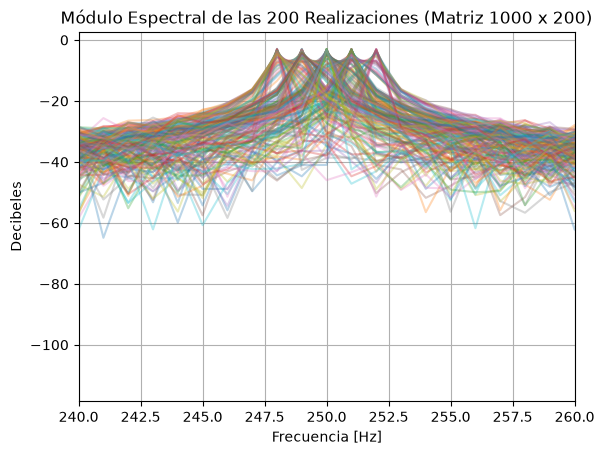

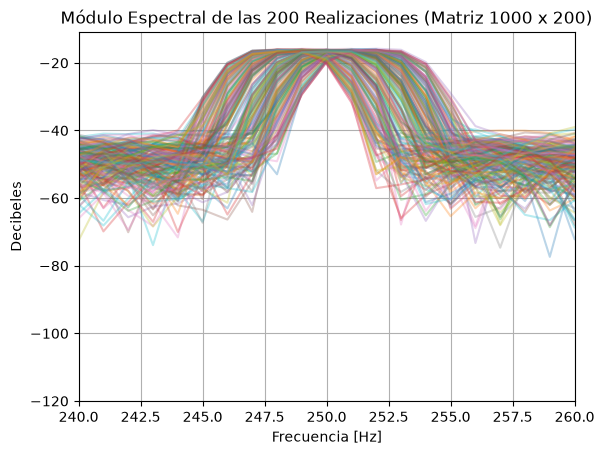

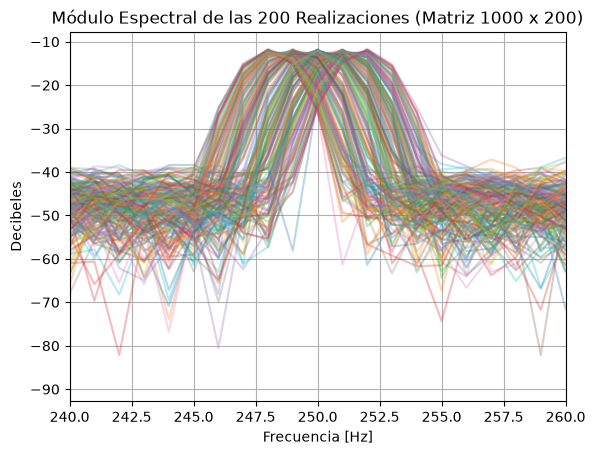

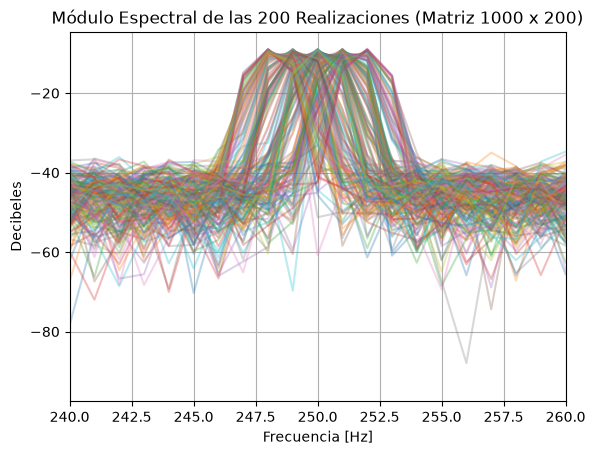

In [5]:
#%% Graficos

######################################
# Grafico de ventana rectangular
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones (Matriz 1000 x 200)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260) 
plt.grid(True)
plt.show()

######################################
# Grafico de ventana flattop
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_flattop, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones (Matriz 1000 x 200)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260) 
plt.grid(True)
plt.show()


######################################
# Grafico de ventana blackman
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_blackman, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones (Matriz 1000 x 200)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260) 
plt.grid(True)
plt.show()

######################################
# Grafico de ventana Hann
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_hann, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones (Matriz 1000 x 200)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260) 
plt.grid(True)
plt.show()


## 4. Análisis estadístico de los estimadores

A partir de las 200 realizaciones se analizaron estadísticamente las estimaciones de frecuencia y amplitud obtenidas para cada caso.

Para la frecuencia, el estimador utilizado fue la posición del máximo espectral:

$$
\hat{f}_i=\underset{f}{\operatorname{arg\,max}}\ |X_i(f)|
$$

Mientras que para la amplitud se utilizó el módulo del coeficiente correspondiente al máximo espectral, considerando el factor de corrección asociado a la representación de la señal sinusoidal.

El objetivo de analizar las 200 realizaciones es determinar qué tan cercanos son los valores estimados a los valores reales y cuánto varían entre una realización y otra.

Para esto se calcularon diferentes parámetros estadísticos, principalmente la media, la varianza y el sesgo de los estimadores.

La media de un conjunto de estimaciones se calcula como:

$$
\mu_{\hat{\theta}}=\frac{1}{R}\sum_{i=1}^{R}\hat{\theta}_i
$$

El sesgo se obtiene comparando el valor medio estimado con el valor verdadero:

$$
Bias(\hat{\theta})=
\mu_{\hat{\theta}}-\theta
$$

Por otra parte, la varianza permite cuantificar la dispersión de las estimaciones alrededor de su valor medio:

$$
Var(\hat{\theta})=
\frac{1}{R}\sum_{i=1}^{R}
(\hat{\theta}_i-\mu_{\hat{\theta}})^2
$$

Estos parámetros permiten evaluar de manera cuantitativa el comportamiento de los estimadores para cada una de las ventanas utilizadas.

### Histogramas de los estimadores

Para complementar el análisis estadístico se construyeron histogramas de las estimaciones de frecuencia y amplitud obtenidas en las 200 realizaciones.

Los histogramas permiten visualizar la distribución de los resultados y observar de manera directa dónde se concentran las estimaciones y qué dispersión presentan.

En el caso de la frecuencia, se puede comparar la distribución obtenida con el valor nominal de $250$ Hz. Para la amplitud, se compara la distribución con el valor teórico correspondiente a la señal utilizada.

La comparación de los histogramas correspondientes a las distintas ventanas permite observar cómo cambia la dispersión y el desplazamiento de las estimaciones al modificar el procesamiento aplicado a la señal.

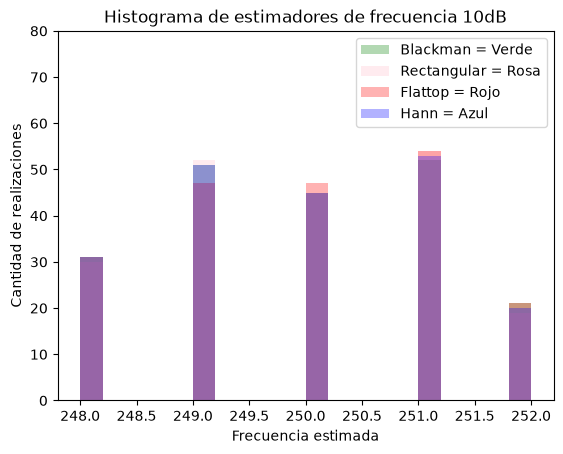

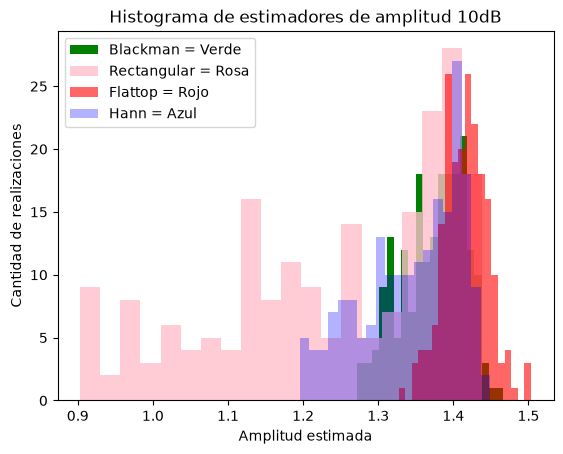

In [6]:
######################################
# Grafico de los histogramas
######################################

# FRECUENCIA

plt.figure()
plt.hist(om_blackman, bins = 20, alpha = 0.3, label= 'Blackman', color= 'Green')
plt.hist(om_f, bins = 20, alpha = 0.3, label= 'Rectangular', color= 'Pink')
plt.hist(om_flattop, bins = 20, alpha = 0.3, label= 'Flattop', color= 'Red')
plt.hist(om_hann, bins = 20, alpha = 0.3, label= 'Hann', color= 'Blue')
plt.ylim(0, 80)
plt.legend(['Blackman = Verde', 'Rectangular = Rosa', 'Flattop = Rojo', 'Hann = Azul'])
plt.xlabel('Frecuencia estimada')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de estimadores de frecuencia 10dB')
plt.show() 

# AMPLITUD

plt.figure()
plt.hist(a_1_2_blackman, bins = 20, alpha = 1, label= 'Blackman', color= 'Green')
plt.hist(a_1_2, bins = 20, alpha = 0.8, label= 'Rectangular', color= 'Pink')
plt.hist(a_1_2_flattop, bins = 20, alpha = 0.6, label= 'Flattop', color= 'Red')
plt.hist(a_1_2_hann, bins = 20, alpha = 0.3, label= 'Hann', color= 'Blue')
plt.legend(['Blackman = Verde', 'Rectangular = Rosa', 'Flattop = Rojo', 'Hann = Azul'])
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de estimadores de amplitud 10dB')
plt.show() 

### Comparación de los resultados

Finalmente, se organizaron los valores obtenidos para la media, varianza y sesgo de los estimadores en tablas.

Estas tablas permiten comparar cuantitativamente los resultados obtenidos mediante las diferentes ventanas y complementar la información observada en los histogramas.

De esta manera, el análisis no se limita a la observación visual de los espectros, sino que también permite estudiar estadísticamente el comportamiento de los estimadores de frecuencia y amplitud.

In [7]:
#%% Cuadros de estimadores



###########################
# Sesgo rectangular
###########################

MediaRec = np.mean(a_1_2) #Calcula el valor medio de las estimaciones que hace
VarRec = np.var(a_1_2)
# Calculo sesgo, restando el valor original con obtenido

sesgoRec = MediaRec - a0

print('ESTIMADORES DE AMPLITUD')

print('---------------------------------------------')
print('Sesgo y Varianza de ventana rectangular en 10dB')
print('Sesgo rec= ', sesgoRec)
print('Varianza rec=', VarRec)

###########################
# Sesgo flattop
###########################

MediaFlat = np.mean(a_1_2_flattop)
VarFlat = np.var(a_1_2_flattop)
sesgoFlat = MediaFlat - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana falttop en 10dB')
print('Sesgo flat= ', sesgoFlat)
print('Varianza flat=', VarFlat)

###########################
# Sesgo blackman
###########################

MediaBlack = np.mean(a_1_2_blackman)
VarBlack = np.var(a_1_2_blackman)
sesgoBlack = MediaBlack - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana blackman en 10dB')
print('Sesgo black= ', sesgoBlack)
print('Varianza black=', VarBlack)

###########################
# Sesgo Hann
###########################

MediaHann = np.mean(a_1_2_hann)
VarHann = np.var(a_1_2_hann)
sesgoHann = MediaHann - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana Hann en 10dB')
print('Sesgo black= ', sesgoHann)
print('Varianza black=', VarHann)

##################################################################################
#FRECUENCIA
##################################################################################

###########################
# Sesgo rectangular
###########################

MediaRecOm = np.mean(om_f) 
VarRecOm = np.var(om_f)


sesgoRecOm = MediaRecOm - omega0

print('________________________________________________ ')
print('ESTIMADORES DE FRECUENCIA')

print('---------------------------------------------')
print('Sesgo y Varianza de ventana rectangular en 10dB')
print('Sesgo rec= ', sesgoRecOm)
print('Varianza rec=', VarRecOm)

###########################
# Sesgo flattop
###########################

MediaFlatOm = np.mean(om_flattop)
VarFlatOm = np.var(om_flattop)
sesgoFlatOm = MediaFlatOm - omega0 

print('---------------------------------------------')
print('Sesgo y Varianza de ventana falttop en 10dB')
print('Sesgo flat= ', sesgoFlatOm)
print('Varianza flat=', VarFlatOm)

###########################
# Sesgo blackman
###########################

MediaBlackOm = np.mean(om_blackman)
VarBlackOm = np.var(om_blackman)
sesgoBlackOm = MediaBlackOm - omega0 

print('---------------------------------------------')
print('Sesgo y Varianza de ventana blackman en 10dB')
print('Sesgo black= ', sesgoBlackOm)
print('Varianza black=', VarBlackOm)

###########################
# Sesgo Hann
###########################

MediaHannOm = np.mean(om_hann)
VarHannOm = np.var(om_hann)
sesgoHannOm = MediaHannOm - omega0 

print('---------------------------------------------')
print('Sesgo y Varianza de ventana Hann en 10dB')
print('Sesgo black= ', sesgoHannOm)
print('Varianza black=', VarHannOm)

ESTIMADORES DE AMPLITUD
---------------------------------------------
Sesgo y Varianza de ventana rectangular en 10dB
Sesgo rec=  -0.17209704412091464
Varianza rec= 0.023869134158732246
---------------------------------------------
Sesgo y Varianza de ventana falttop en 10dB
Sesgo flat=  0.0013427203825029377
Varianza flat= 0.0008513047981362581
---------------------------------------------
Sesgo y Varianza de ventana blackman en 10dB
Sesgo black=  -0.04122316567967976
Varianza black= 0.0017501047955937278
---------------------------------------------
Sesgo y Varianza de ventana Hann en 10dB
Sesgo black=  -0.06939267204832689
Varianza black= 0.00414286467353963
________________________________________________ 
ESTIMADORES DE FRECUENCIA
---------------------------------------------
Sesgo y Varianza de ventana rectangular en 10dB
Sesgo rec=  -0.09999999999999432
Varianza rec= 1.4999999999999998
---------------------------------------------
Sesgo y Varianza de ventana falttop en 10dB
Sesg

## 5. Repetición del experimento con una SNR de 3 dB

Finalmente, se repitió el experimento utilizando una relación señal-ruido de $3$ dB, manteniendo el resto de los parámetros del experimento.

La reducción de la SNR implica un aumento de la potencia del ruido respecto de la señal. Nuevamente, la potencia del ruido se calculó mediante:

$$
P_n=\frac{P_s}{10^{SNR_{dB}/10}}
$$

En este caso:

$$
SNR_{dB}=3\ \text{dB}
$$

por lo que la potencia de ruido utilizada es mayor que en el experimento anterior.

Se repitió el mismo procedimiento de generación de las realizaciones, cálculo de la FFT, aplicación de las ventanas y estimación de frecuencia y amplitud.

A partir de los resultados obtenidos se calcularon nuevamente los parámetros estadísticos de los estimadores.

Este segundo experimento permite analizar cómo el aumento del nivel de ruido afecta el comportamiento de las estimaciones y comparar los resultados obtenidos con los correspondientes a una SNR de $10$ dB.

En particular, se espera que una mayor presencia de ruido produzca una mayor dispersión en las estimaciones, lo que puede observarse mediante los valores de varianza y mediante la distribución de los histogramas.

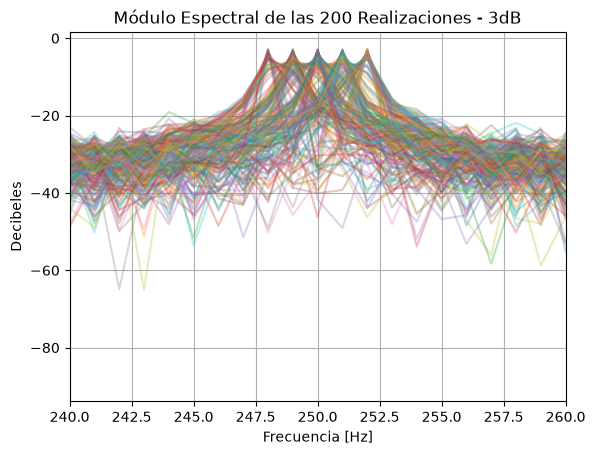

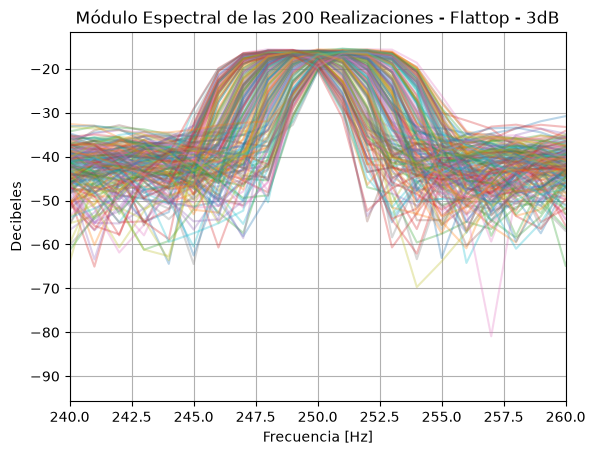

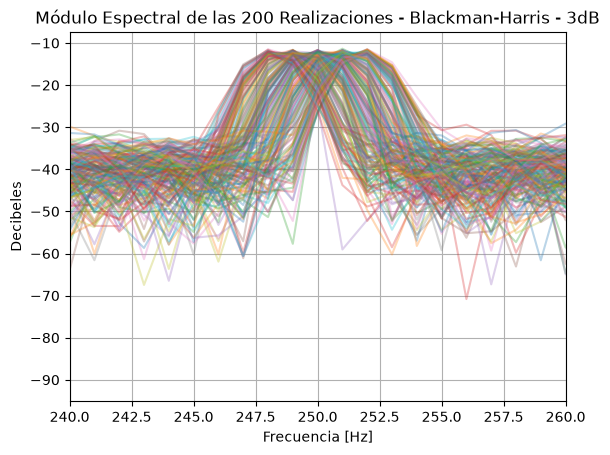

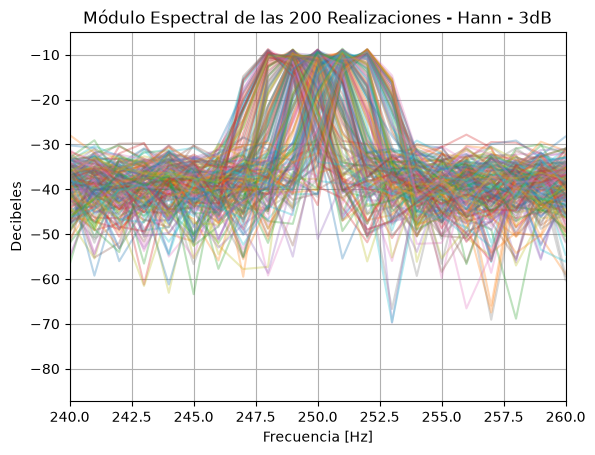

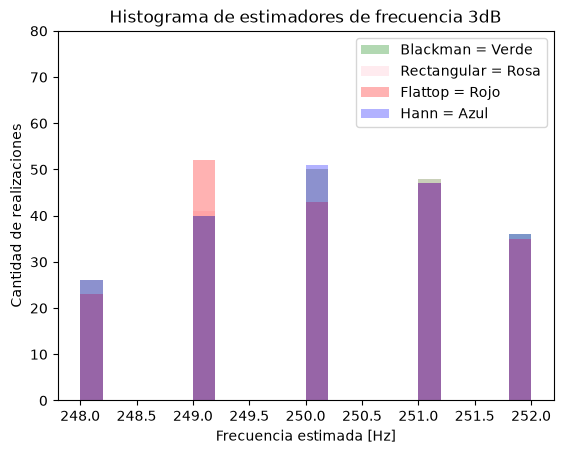

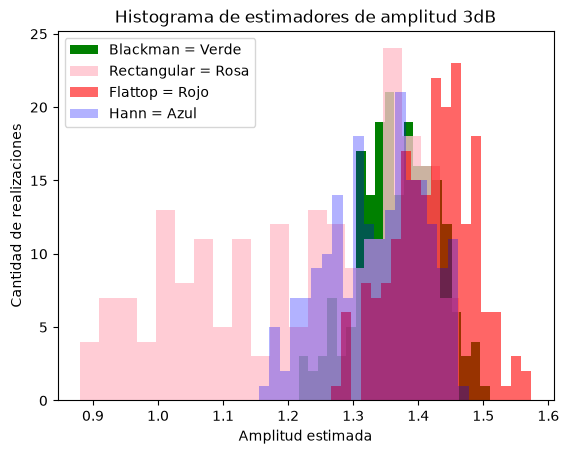

ESTIMADORES DE AMPLITUD - 3dB
---------------------------------------------
Sesgo y Varianza de ventana rectangular en 3dB
Sesgo rec=  -0.1940107019215691
Varianza rec= 0.02653851659163166
---------------------------------------------
Sesgo y Varianza de ventana flattop en 3dB
Sesgo flat=  0.008831375346085135
Varianza flat= 0.0037082495468407474
---------------------------------------------
Sesgo y Varianza de ventana blackman en 3dB
Sesgo black=  -0.04478615682279097
Varianza black= 0.0033733825131403916
---------------------------------------------
Sesgo y Varianza de ventana Hann en 3dB
Sesgo Hann=  -0.07752695702297396
Varianza Hann= 0.00551404522442524
________________________________________________ 
ESTIMADORES DE FRECUENCIA - 3dB
---------------------------------------------
Sesgo y Varianza de ventana rectangular en 3dB
Sesgo rec=  0.125
Varianza rec= 1.649375
---------------------------------------------
Sesgo y Varianza de ventana flattop en 3dB
Sesgo flat=  0.0949999999999

In [8]:
#%% EXPERIMENTO 3 dB

snr_db_3 = 3
varianza_3 = P_s / (10**(snr_db_3 / 10))
sigma_3 = np.sqrt(varianza_3)

#%% Condicionando las variables

# Hacer las de ruido
Na_3 = np.random.normal(0.0, sigma_3, (N, R))

fr_3 = np.random.uniform(-limiteUniforme, limiteUniforme, R)

# Matrices
n_col_3 = np.arange(N).reshape(N, 1)

omega1_3 = 2 * np.pi * (omega0 + fr_3) / fs

omega1_3 = omega1_3.reshape(1, R)

#%% Creacion de funciones

# Hago mi funcion
f_sen_3 = a0 * np.sin(omega1_3 * n_col_3) + Na_3


#FFT
f_fft_3 = (1/N) * np.fft.fft(f_sen_3, axis=0)

potencia_lineal_3 = (np.abs(f_fft_3[:N // 2, :]))**2

dens_pot_3 = 10 * np.log10(potencia_lineal_3 + 1e-12)


# Estimador de frecuencia
indice_pico_3 = np.argmax(np.abs(f_fft_3[:N // 2, :]), axis=0)

om_f_3 = ff_vector_pos[indice_pico_3]

# Estimador de amplitud
a_1_2_3 = 2 * np.abs(f_fft_3[indice_pico_3, np.arange(R)])


#%% Ventanas

# La rectangular ya esta hecha porque es multiplicado por uno


####################################################
# FLATTOP
####################################################

f_flattop_3 = f_sen_3 * sg.flattop(N).reshape(N, 1)

f_flattop_fft_3 = (1/N) * np.fft.fft(f_flattop_3, axis=0)

potencia_lineal_flattop_3 = (np.abs(f_flattop_fft_3[:N // 2, :]))**2

dens_pot_flattop_3 = 10 * np.log10(potencia_lineal_flattop_3 + 1e-12)

# Estimador de amplitud
indice_pico_flattop_3 = np.argmax(np.abs(f_flattop_fft_3[:N // 2, :]), axis=0)

a_1_2_flattop_3 = (2 * np.abs(f_flattop_fft_3[indice_pico_flattop_3, np.arange(R)])) / np.mean(sg.flattop(N))

# Estimador de frecuencia
om_flattop_3 = ff_vector_pos[indice_pico_flattop_3]


####################################################
# BLACKMANHARRIS
####################################################

f_blackman_3 = f_sen_3 * sg.blackmanharris(N).reshape(N, 1)

f_blackman_fft_3 = (1/N) * np.fft.fft(f_blackman_3, axis=0)

potencia_lineal_blackman_3 = (np.abs(f_blackman_fft_3[:N // 2, :]))**2

dens_pot_blackman_3 = 10 * np.log10(potencia_lineal_blackman_3 + 1e-12)

# Estimador de amplitud
indice_pico_blackman_3 = np.argmax(np.abs(f_blackman_fft_3[:N // 2, :]), axis=0)

a_1_2_blackman_3 = (2 * np.abs(f_blackman_fft_3[indice_pico_blackman_3, np.arange(R)])) / np.mean(sg.blackmanharris(N))

# Estimador de frecuencia
om_blackman_3 = ff_vector_pos[indice_pico_blackman_3]


####################################################
# HANN
####################################################

f_hann_3 = f_sen_3 * sg.hann(N).reshape(N, 1)

f_hann_fft_3 = (1/N) * np.fft.fft(f_hann_3, axis=0)

potencia_lineal_hann_3 = (np.abs(f_hann_fft_3[:N // 2, :]))**2

dens_pot_hann_3 = 10 * np.log10(potencia_lineal_hann_3 + 1e-12)

# Estimador de amplitud
indice_pico_hann_3 = np.argmax(np.abs(f_hann_fft_3[:N // 2, :]), axis=0)

a_1_2_hann_3 = (2 * np.abs(f_hann_fft_3[indice_pico_hann_3, np.arange(R)])) / np.mean(sg.hann(N))

# Estimador de frecuencia
om_hann_3 = ff_vector_pos[indice_pico_hann_3]


#%% Graficos

######################################
# Grafico de ventana rectangular
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_3, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones - 3dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260)
plt.grid(True)
plt.show()


######################################
# Grafico de ventana flattop
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_flattop_3, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones - Flattop - 3dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260)
plt.grid(True)
plt.show()


######################################
# Grafico de ventana blackman
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_blackman_3, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones - Blackman-Harris - 3dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260)
plt.grid(True)
plt.show()


######################################
# Grafico de ventana Hann
######################################

plt.figure()
plt.plot(ff_vector_pos, dens_pot_hann_3, alpha=0.3)
plt.title('Módulo Espectral de las 200 Realizaciones - Hann - 3dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Decibeles')
plt.xlim(240, 260)
plt.grid(True)
plt.show()


######################################
# Grafico de los histogramas
######################################

# FRECUENCIA

plt.figure()
plt.hist(om_blackman_3, bins=20, alpha=0.3, label='Blackman', color='Green')
plt.hist(om_f_3, bins=20, alpha=0.3, label='Rectangular', color='Pink')
plt.hist(om_flattop_3, bins=20, alpha=0.3, label='Flattop', color='Red')
plt.hist(om_hann_3, bins=20, alpha=0.3, label='Hann', color='Blue')
plt.ylim(0, 80)
plt.legend(['Blackman = Verde', 'Rectangular = Rosa', 'Flattop = Rojo', 'Hann = Azul'])
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de estimadores de frecuencia 3dB')
plt.show()


# AMPLITUD

plt.figure()
plt.hist(a_1_2_blackman_3, bins=20, alpha=1, label='Blackman', color='Green')
plt.hist(a_1_2_3, bins=20, alpha=0.8, label='Rectangular', color='Pink')
plt.hist(a_1_2_flattop_3, bins=20, alpha=0.6, label='Flattop', color='Red')
plt.hist(a_1_2_hann_3, bins=20, alpha=0.3, label='Hann', color='Blue')
plt.legend(['Blackman = Verde', 'Rectangular = Rosa', 'Flattop = Rojo', 'Hann = Azul'])
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.title('Histograma de estimadores de amplitud 3dB')
plt.show()


#%% Cuadros de estimadores 3dB


###########################
# AMPLITUD
###########################

MediaRec_3 = np.mean(a_1_2_3)
VarRec_3 = np.var(a_1_2_3)

sesgoRec_3 = MediaRec_3 - a0

print('ESTIMADORES DE AMPLITUD - 3dB')

print('---------------------------------------------')
print('Sesgo y Varianza de ventana rectangular en 3dB')
print('Sesgo rec= ', sesgoRec_3)
print('Varianza rec=', VarRec_3)


###########################
# Sesgo flattop
###########################

MediaFlat_3 = np.mean(a_1_2_flattop_3)
VarFlat_3 = np.var(a_1_2_flattop_3)

sesgoFlat_3 = MediaFlat_3 - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana flattop en 3dB')
print('Sesgo flat= ', sesgoFlat_3)
print('Varianza flat=', VarFlat_3)


###########################
# Sesgo blackman
###########################

MediaBlack_3 = np.mean(a_1_2_blackman_3)
VarBlack_3 = np.var(a_1_2_blackman_3)

sesgoBlack_3 = MediaBlack_3 - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana blackman en 3dB')
print('Sesgo black= ', sesgoBlack_3)
print('Varianza black=', VarBlack_3)


###########################
# Sesgo Hann
###########################

MediaHann_3 = np.mean(a_1_2_hann_3)
VarHann_3 = np.var(a_1_2_hann_3)

sesgoHann_3 = MediaHann_3 - a0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana Hann en 3dB')
print('Sesgo Hann= ', sesgoHann_3)
print('Varianza Hann=', VarHann_3)


##################################################################################
# FRECUENCIA
##################################################################################

###########################
# Sesgo rectangular
###########################

MediaRecOm_3 = np.mean(om_f_3)
VarRecOm_3 = np.var(om_f_3)

sesgoRecOm_3 = MediaRecOm_3 - omega0

print('________________________________________________ ')
print('ESTIMADORES DE FRECUENCIA - 3dB')

print('---------------------------------------------')
print('Sesgo y Varianza de ventana rectangular en 3dB')
print('Sesgo rec= ', sesgoRecOm_3)
print('Varianza rec=', VarRecOm_3)


###########################
# Sesgo flattop
###########################

MediaFlatOm_3 = np.mean(om_flattop_3)
VarFlatOm_3 = np.var(om_flattop_3)

sesgoFlatOm_3 = MediaFlatOm_3 - omega0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana flattop en 3dB')
print('Sesgo flat= ', sesgoFlatOm_3)
print('Varianza flat=', VarFlatOm_3)


###########################
# Sesgo blackman
###########################

MediaBlackOm_3 = np.mean(om_blackman_3)
VarBlackOm_3 = np.var(om_blackman_3)

sesgoBlackOm_3 = MediaBlackOm_3 - omega0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana blackman en 3dB')
print('Sesgo black= ', sesgoBlackOm_3)
print('Varianza black=', VarBlackOm_3)


###########################
# Sesgo Hann
###########################

MediaHannOm_3 = np.mean(om_hann_3)
VarHannOm_3 = np.var(om_hann_3)

sesgoHannOm_3 = MediaHannOm_3 - omega0

print('---------------------------------------------')
print('Sesgo y Varianza de ventana Hann en 3dB')
print('Sesgo Hann= ', sesgoHannOm_3)
print('Varianza Hann=', VarHannOm_3)

# Conclusión

A partir del desarrollo del trabajo se pudo analizar el comportamiento de distintos estimadores espectrales aplicados a una señal senoidal contaminada con ruido. Se realizaron 200 realizaciones independientes y se estudiaron dos condiciones de relación señal-ruido, 10 dB y 3 dB, permitiendo observar cómo el aumento del nivel de ruido afecta la estimación de los parámetros de la señal.

Para cada realización se estimaron la frecuencia y la amplitud a partir de la Transformada de Fourier. En el caso de la frecuencia, se buscó la posición del máximo del módulo de la FFT, mientras que para la amplitud se utilizó el valor del espectro correspondiente al pico encontrado. A partir de las diferentes realizaciones fue posible analizar estadísticamente los estimadores mediante su media, varianza y sesgo.

También se compararon diferentes ventanas: rectangular, Flattop, Blackman-Harris y Hann. La utilización de estas ventanas modifica la representación espectral de la señal y, por lo tanto, puede afectar el comportamiento de los estimadores. El análisis de los histogramas y de los valores estadísticos permitió observar estas diferencias y relacionarlas con las características de cada ventana.

La comparación entre los casos de 10 dB y 3 dB permitió además analizar la influencia del ruido sobre las estimaciones. Al disminuir la relación señal-ruido, el ruido adquiere una mayor influencia sobre el espectro, lo que puede producir una mayor dispersión en las estimaciones obtenidas.

En conclusión, el trabajo permitió aplicar en forma práctica conceptos relacionados con la Transformada de Fourier, el análisis espectral, el uso de ventanas y la estimación estadística de parámetros. Además, permitió comprender la importancia de analizar no solamente una estimación individual, sino el comportamiento de un estimador a partir de múltiples realizaciones de una señal.